In [1]:
import pandas as pd
import numpy as np

import spacy
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


# Analyse des verbatims clients – Assurance Auto

## Objectif
Analyser des commentaires clients issus d’un fichier CSV afin d’identifier
les principaux irritants et thèmes récurrents à l’aide du NLP et du topic modeling (BERTopic).

Ce notebook prépare également le terrain pour une future application Streamlit.


## 1. Chargement des données

Le fichier CSV contient des commentaires clients liés à l’assurance auto.
Certaines lignes peuvent être mal formées, elles seront ignorées.


In [2]:
FILE_PATH = "commentaires_assurance_auto.csv"

columns = [
    "id", "date_commentaire", "device", "canal", "sentiment",
    "type_irritant", "type_sinistre", "anciennete_client",
    "type_contrat", "csat", "gravite_sinistre",
    "region_client", "canal_resolution", "commentaire"
]

df = pd.read_csv(
    FILE_PATH,
    sep=";",
    header=None,
    names=columns,
    on_bad_lines="skip"
)

df.head()


,id,date_commentaire,device,canal,sentiment,type_irritant,type_sinistre,anciennete_client,type_contrat,csat,gravite_sinistre,region_client,canal_resolution,commentaire
0,1,2024-11-23,Android,Web,neg,photo,collision,3-10 ans,tous_risques,2,faible,Île-de-France,App,"Très mécontent, les photos restent en attente ..."
1,2,2024-03-22,iOS,App,neg,complexité,collision,0-1 an,tiers,2,moyenne,Pays de la Loire,Téléphone,"Je suis déçu, c'est trop technique pour un sin..."
2,3,2024-04-26,iOS,Email,pos,authentification,collision,3-10 ans,jeune_conducteur,4,faible,Auvergne-Rhône-Alpes,App,"Très satisfait, ça bloque sur l'authentificati..."
3,4,2024-04-22,iOS,Web,neu,photo,collision,1-3 ans,tiers,3,faible,Bourgogne-Franche-Comté,Email,"Ça pourrait être mieux, l'envoi des clichés éc..."
4,5,2024-10-02,Android,Web,pos,lenteur,collision,10+ ans,tous_risques,4,moyenne,Bretagne,App,"Merci, le site rame énormément quand je joins ..."


## 2. Préparation des données

- Conversion des types (date, CSAT)
- Vérification des valeurs manquantes
- Sélection de la colonne texte à analyser


In [3]:
df["date_commentaire"] = pd.to_datetime(df["date_commentaire"], errors="coerce")
df["csat"] = pd.to_numeric(df["csat"], errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8650 entries, 0 to 8649
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 8650 non-null   int64         
 1   date_commentaire   8650 non-null   datetime64[ns]
 2   device             8650 non-null   object        
 3   canal              8650 non-null   object        
 4   sentiment          8650 non-null   object        
 5   type_irritant      8650 non-null   object        
 6   type_sinistre      8650 non-null   object        
 7   anciennete_client  8650 non-null   object        
 8   type_contrat       8650 non-null   object        
 9   csat               8650 non-null   int64         
 10  gravite_sinistre   8650 non-null   object        
 11  region_client      8650 non-null   object        
 12  canal_resolution   8650 non-null   object        
 13  commentaire        8650 non-null   object        
dtypes: datet

## 3. Nettoyage du texte (spaCy)

Objectifs :
- lemmatisation
- suppression des stopwords, ponctuation, nombres
- normalisation du texte

On utilise `nlp.pipe()` pour de meilleures performances.


In [4]:
nlp = spacy.load("fr_core_news_md")


In [5]:
def clean_text_spacy(texts, nlp, batch_size=64):
    cleaned = []
    generator = ("" if t is None else str(t) for t in texts)

    for doc in nlp.pipe(generator, batch_size=batch_size):
        tokens = [
            tok.lemma_.lower().strip()
            for tok in doc
            if not tok.is_stop
            and not tok.is_punct
            and not tok.like_num
            and len(tok) >= 2   # <- assoupli (avant: > 2)
        ]
        cleaned.append(" ".join(tokens))
    return cleaned


In [6]:
df["commentaire_clean"] = clean_text_spacy(df["commentaire"], nlp)
df[["commentaire", "commentaire_clean"]].head(5)


,commentaire,commentaire_clean
0,"Très mécontent, les photos restent en attente ...",mécontent photo attente fin formulaire essai c...
1,"Je suis déçu, c'est trop technique pour un sin...",décevoir trop technique sinistre simple perdre...
2,"Très satisfait, ça bloque sur l'authentificati...",satisfait bloquer authentification valide code...
3,"Ça pourrait être mieux, l'envoi des clichés éc...",mieux envoi cliché échouer étape justificatif ...
4,"Merci, le site rame énormément quand je joins ...",site rame énormément joindre pièce résolution ...


## 4. Vectorisation du texte (embeddings)

On transforme les commentaires nettoyés en vecteurs numériques
à l’aide d’un modèle multilingue SentenceTransformer.


In [7]:
# Sécurité : on enlève les lignes vides après nettoyage (important pour la stabilité)
df = df[df["commentaire_clean"].str.strip().ne("")].reset_index(drop=True)
df.shape


(8650, 15)

In [8]:
import os

# Dossier cache Hugging Face (mets un chemin qui existe chez toi)
os.environ["HF_HOME"] = "./hf_cache"
os.environ["TRANSFORMERS_CACHE"] = "./hf_cache"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"  # accélère parfois


In [9]:
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")


In [10]:
embeddings = embedder.encode(
    df["commentaire_clean"].tolist(),
    show_progress_bar=True
)


Batches:   0%|          | 0/271 [00:00<?, ?it/s]

## 5. Topic Modeling avec BERTopic

BERTopic permet d’identifier automatiquement des thèmes récurrents
dans les commentaires clients à partir des embeddings.


In [11]:
topic_model = BERTopic(
    language="multilingual",
    nr_topics=15,        # <- force ~15 thèmes (au lieu de centaines)
    min_topic_size=50,   # <- évite les micro-topics
    calculate_probabilities=False,
    verbose=True
)

topics, _ = topic_model.fit_transform(
    df["commentaire_clean"].tolist(),
    embeddings
)

df["topic"] = topics
df["topic"].value_counts().head(10)


2026-01-22 07:32:42,259 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-01-22 07:34:04,129 - BERTopic - Dimensionality - Completed ✓
2026-01-22 07:34:04,131 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-22 07:34:05,443 - BERTopic - Cluster - Completed ✓
2026-01-22 07:34:05,443 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-01-22 07:34:05,938 - BERTopic - Representation - Completed ✓
2026-01-22 07:34:05,941 - BERTopic - Topic reduction - Reducing number of topics
2026-01-22 07:34:05,982 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-22 07:34:06,143 - BERTopic - Representation - Completed ✓
2026-01-22 07:34:06,151 - BERTopic - Topic reduction - Reduced number of topics from 43 to 15


topic
 0    2127
 1    2025
-1     805
 2     766
 3     405
 4     393
 5     360
 6     327
 7     324
 8     229
Name: count, dtype: int64

## 6. Interprétation des topics

On génère des labels lisibles à partir des mots-clés principaux de chaque topic.


In [12]:
def make_topic_labels(topic_model, top_n_words=3):
    labels = {}
    info = topic_model.get_topic_info()

    for tid in info["Topic"]:
        if tid == -1:
            labels[tid] = "Outliers"
            continue

        terms = topic_model.get_topic(tid)
        if not terms:
            labels[tid] = f"Topic {tid}"
            continue

        words = [w for w, _ in terms[:top_n_words]]
        labels[tid] = " / ".join(words)

    return labels



In [13]:
topic_labels = make_topic_labels(topic_model, top_n_words=3)
df["topic_label"] = df["topic"].map(topic_labels)

df[["commentaire", "topic", "topic_label"]].head(10)


,commentaire,topic,topic_label
0,"Très mécontent, les photos restent en attente ...",0,photo / attente / ajout
1,"Je suis déçu, c'est trop technique pour un sin...",1,perdre / trop / rien
2,"Très satisfait, ça bloque sur l'authentificati...",11,id / face / reconnaissance
3,"Ça pourrait être mieux, l'envoi des clichés éc...",-1,Outliers
4,"Merci, le site rame énormément quand je joins ...",0,photo / attente / ajout
5,"Merci, ça me déconnecte tout seul sur mon télé...",4,téléphone / sms / code
6,"Je suis déçu, la caméra ne s'ouvre pas même en...",0,photo / attente / ajout
7,"Je suis déçu, le parcours est confus pour une ...",1,perdre / trop / rien
8,"Très satisfait, l'ajout des photos bloque au m...",0,photo / attente / ajout
9,"Je suis déçu, l'application plante après la mi...",13,application / plant / confirmer


## 7. Analyse métier

On analyse la répartition des thèmes et leur lien avec :
- le sentiment
- le canal
- le device
- le CSAT


In [23]:
label_map = {
    "photo / attente / ajout": "Dépôt de photos lent",
    "perdre / trop / rien": "Perte d'informations",
    "onglet / écran / bouton": "Problèmes d'interface",
    "page / figer / clic": "Application figée",
    "téléphone / sms / code": "Authentification SMS"
}

df["topic_label_clean"] = df["topic_label"].replace(label_map)


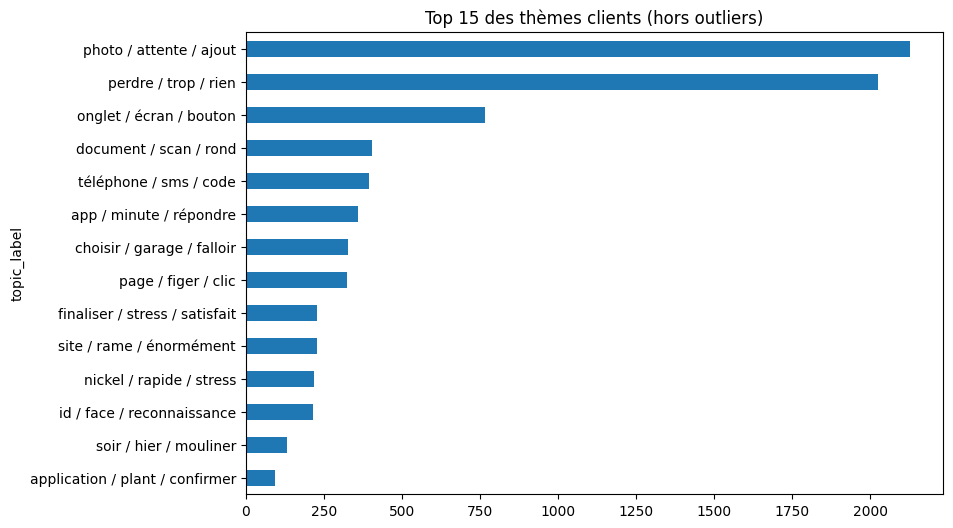

In [24]:
plot_df = df[df["topic_label"] != "Outliers"]

top_topics = (
    plot_df["topic_label"]
    .value_counts()
    .head(15)
    .sort_values()
)

top_topics.plot(kind="barh", figsize=(9, 6))
plt.title("Top 15 des thèmes clients (hors outliers)")
plt.show()


Les résultats montrent que les principaux irritants clients sont liés à des problèmes techniques et d’expérience utilisateur sur les parcours digitaux.

Les difficultés de dépôt de photos et de documents représentent le premier motif d’insatisfaction, suivies par des frustrations liées à la perte d’informations et à la navigation dans l’application.

Les problématiques d’authentification et de lenteur du système apparaissent également de manière récurrente, confirmant un impact significatif de la performance technique sur la satisfaction client.

In [25]:
label_map = {
    "photo / attente / ajout": "Dépôt de photos lent ou bloqué",
    "perdre / trop / rien": "Perte d’informations dans le parcours",
    "onglet / écran / bouton": "Problèmes d’interface utilisateur",
    "document / scan / rond": "Dépôt / scan de documents",
    "téléphone / sms / code": "Authentification par SMS"
}

df["topic_label_exec"] = df["topic_label"].replace(label_map)


In [26]:
csat_by_topic = (
    df[df["topic_label"] != "Outliers"]
    .groupby("topic_label", as_index=False)
    .agg(
        count=("csat", "size"),
        csat_mean=("csat", "mean")
    )
    .sort_values("csat_mean")
)

csat_by_topic


,topic_label,count,csat_mean
12,soir / hier / mouliner,131,1.755725
9,perdre / trop / rien,2025,1.846420
1,application / plant / confirmer,95,1.894737
3,document / scan / rond,405,1.938272
7,onglet / écran / bouton,766,1.981723
5,id / face / reconnaissance,216,2.087963
2,choisir / garage / falloir,327,2.207951
13,téléphone / sms / code,393,2.262087
11,site / rame / énormément,228,2.267544
8,page / figer / clic,324,2.271605


## Lecture métier des résultats

L’analyse des verbatims clients met en évidence un nombre limité de thèmes dominants,
qui concentrent l’essentiel de l’insatisfaction.

Les irritants les plus fréquents concernent principalement :
- le dépôt de photos et de documents, perçu comme lent ou bloquant
- la perte d’informations au cours du parcours utilisateur
- des problèmes d’interface (boutons, écrans, navigation)
- des difficultés d’authentification et de validation

Ces problématiques sont majoritairement liées aux parcours digitaux et à la performance
technique de l’application, ce qui indique un impact direct sur l’expérience client.


In [27]:
summary = (
    df[df["topic_label"] != "Outliers"]["topic_label"]
    .value_counts(normalize=True)
    .head(10)
    .reset_index()
)

summary.columns = ["theme", "part"]
summary["part_pct"] = (summary["part"] * 100).round(1)

summary[["theme", "part_pct"]]


,theme,part_pct
0,photo / attente / ajout,27.1
1,perdre / trop / rien,25.8
2,onglet / écran / bouton,9.8
3,document / scan / rond,5.2
4,téléphone / sms / code,5.0
5,app / minute / répondre,4.6
6,choisir / garage / falloir,4.2
7,page / figer / clic,4.1
8,finaliser / stress / satisfait,2.9
9,site / rame / énormément,2.9


## Interprétation du résumé

Les dix principaux thèmes représentent une part majoritaire des commentaires analysés,
ce qui confirme que l’insatisfaction client est concentrée autour de quelques irritants
clairs et récurrents.

Cette concentration permet de prioriser efficacement les actions correctives, en se
focalisant sur un nombre limité de problématiques à fort impact.


In [29]:
def show_examples_by_topic(df, n_topics=5, n_examples=3):
    for label in (
        df[df["topic_label"] != "Outliers"]["topic_label"]
        .value_counts()
        .head(n_topics)
        .index
    ):
        print("\n" + "=" * 80)
        print(f"THÈME : {label}")
        subset = (
            df.loc[df["topic_label"] == label, "commentaire"]
            .dropna()
            .head(n_examples)
        )
        for i, txt in enumerate(subset, 1):
            print(f"{i}. {txt}")

show_examples_by_topic(df, n_topics=5, n_examples=3)



THÈME : photo / attente / ajout
1. Très mécontent, les photos restent en attente à la fin du formulaire malgré plusieurs essais, du coup rien n'avance, merci quand même.
2. Merci, le site rame énormément quand je joins une pièce mais la résolution a été rapide, franchement j'ai eu une réponse rapide, service efficace.
3. Je suis déçu, la caméra ne s'ouvre pas même en 4G et je perds tout, honnêtement rien n'avance, j'espère que ça ira mieux.

THÈME : perdre / trop / rien
1. Je suis déçu, c'est trop technique pour un sinistre simple et je perds tout, franchement je perds un temps fou, c'est pas sérieux.
2. Je suis déçu, le parcours est confus pour une simple déclaration et je perds tout, bref ça bloque encore, j'ai fini par appeler.
3. Très satisfait, le lien de connexion expire quand je valide le code au début, puis tout s'est débloqué rapidement.

THÈME : onglet / écran / bouton
1. Je suis déçu on tourne en rond dans les écrans entre les onglets et je perds tout bref je perds un temps

## Analyse qualitative

Les verbatims associés aux principaux thèmes confirment les difficultés rencontrées
par les clients dans l’utilisation de l’application.

Les commentaires mettent en évidence :
- des blocages techniques récurrents
- une incompréhension du parcours utilisateur
- un manque de feedback lors des actions critiques (upload, validation)

Ces éléments expliquent la frustration exprimée et renforcent la pertinence des thèmes identifiés.


In [30]:
if "csat" in df.columns:
    csat_by_topic = (
        df[df["topic_label"] != "Outliers"]
        .groupby("topic_label", as_index=False)
        .agg(
            count=("csat", "size"),
            csat_mean=("csat", "mean")
        )
        .sort_values("csat_mean")
    )

    csat_by_topic


## 8. Export des données enrichies

Le fichier exporté pourra être utilisé :
- pour un reporting
- pour une application Streamlit
- pour des analyses ultérieures


In [32]:
OUTPUT_PATH = "commentaires_assurance_auto_topics.csv"
df.to_csv(OUTPUT_PATH, index=False)

print("Fichier exporté :", OUTPUT_PATH)


Fichier exporté : commentaires_assurance_auto_topics.csv


## Conclusion

- Les principaux irritants clients ont été identifiés automatiquement.
- Le topic modeling fournit une lecture synthétique et actionnable des verbatims.
- Ce notebook constitue une base solide pour une application Streamlit interactive.

Prochaines étapes possibles :
- déploiement Streamlit
- suivi temporel des thèmes
- alertes automatiques sur nouveaux irritants
